# Лабораторная 3. Полиномиальная регрессия. Регуляризация. Кросс-валидация

**Задание 3.** Реализовать программно восстановление функциональной зависимости
методом наименьших квадратов с помощью полиномиальной регрессии. Для этого
использовать значения параметра $M \in \{0, 1, \ldots, 15\}$; генерировать
выборку двумя способами, моделируя ошибку измерения как равномерно и как
нормально распределённую случайную величину; значения $x$ генерировать из
заданного интервала случайно в соответствии с равномерным распределением; в
качестве распознаваемых зависимостей использовать
$y = \cos x$, $y = 5x^3 + x^2 + 5$, $y = x \sin x$ на $x \in [0, 2\pi]$.

**Задание 4.** При тех же условиях реализовать регуляризацию и показать, что
переобучение может быть устранено при некоторых значениях $M$ и $\lambda$; найти
эти значения.

**Задание 5.** Реализовать кросс-валидацию для полиномиальной регрессии с
регуляризацией. Определить наилучшую пару $(M, \lambda)$.

## 1. Теория

### Метод наименьших квадратов

Дана выборка $\{(x_k, y_k)\}_{k=1}^{N}$, где $y_k = f(x_k) + \varepsilon_k$ и
$\varepsilon_k$ - ошибка измерения. Полиномиальная регрессия ищет приближение

$$\tilde f(x, w) = \sum_{j=0}^{M} w_j x^j,$$

минимизирующее сумму квадратов отклонений

$$E(w) = \frac12 \sum_{k=1}^{N}\bigl(y_k - \tilde f(x_k, w)\bigr)^2 .$$

Приравнивая нулю производные по $w_i$, получаем систему нормальных уравнений

$$\sum_{j=0}^{M} a_{ij} w_j = b_i,
\qquad a_{ij} = \sum_{k} x_k^{\,i+j},
\qquad b_i = \sum_{k} x_k^{\,i} y_k .$$

В матричном виде $A w = b$, где $A = V^{\top}V$ и $b = V^{\top}y$, а
$V = (x_k^{\,j})$ - матрица Вандермонда. Система однозначно разрешима, когда
число различных узлов не меньше $M + 1$.

### Переобучение

С ростом $M$ модель всё точнее проходит через точки выборки, включая ошибки
измерения. При $M \ge N - 1$ многочлен проходит через все точки в точности, и
ошибка на обучающей выборке падает до нуля, тогда как ошибка на новых данных
растёт неограниченно. Это и есть переобучение: модель запоминает выборку вместо
того, чтобы восстанавливать зависимость.

Внешний признак переобучения - огромные по модулю коэффициенты $w_j$
противоположных знаков, которые почти сокращаются в узлах выборки и дают дикие
выбросы между ними.

### Регуляризация

К функции ошибки добавляется штраф за величину коэффициентов:

$$E_\lambda(w) = \frac12\sum_{k=1}^{N}\bigl(y_k - \tilde f(x_k, w)\bigr)^2
             + \frac{\lambda}{2}\lVert w \rVert^2 .$$

Условие минимума даёт

$$(A + \lambda I)\,w = b .$$

Добавка $\lambda I$ сдвигает все собственные значения $A$ на $\lambda$, поэтому
матрица становится невырожденной и хорошо обусловленной даже при большом $M$, а
решение перестаёт содержать гигантские коэффициенты. Параметр $\lambda$
управляет компромиссом между смещением и дисперсией: при $\lambda \to 0$
получаем обычный МНК с большой дисперсией, при $\lambda \to \infty$ все
коэффициенты стремятся к нулю и модель вырождается в константу с большим
смещением.

### Кросс-валидация

Подбирать $(M, \lambda)$ по ошибке на обучающей выборке нельзя: она монотонно
убывает с ростом $M$. Выборка разбивается на $F$ частей (фолдов); модель
$F$ раз обучается на $F-1$ частях и оценивается на оставшейся; ошибки
усредняются. Полученная оценка не использует тестовых данных и потому годится
для выбора гиперпараметров.

### О масштабировании аргумента

При $x \in [0, 2\pi]$ и $M = 15$ элементы матрицы $A$ различаются на
$(2\pi)^{30} \approx 10^{23}$ порядка, и система становится неразрешимой
численно. Поэтому базис строится не по $x$, а по линейно преобразованному
$t = 2(x - a)/(b - a) - 1 \in [-1, 1]$. Многочлен степени $M$ от $t$ - это тот же
многочлен степени $M$ от $x$, поэтому семейство моделей не меняется, а
обусловленность улучшается на много порядков. Проверим это численно.

## 2. Генерация выборки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

A_INT, B_INT = 0.0, 2 * np.pi

FUNCS = {
    'cos x': lambda x: np.cos(x),
    '5x^3 + x^2 + 5': lambda x: 5 * x ** 3 + x ** 2 + 5,
    'x sin x': lambda x: x * np.sin(x),
}

In [2]:
def make_sample(f, n, noise, eps, rng):
    """x равномерно на [0, 2pi]; ошибка равномерная либо нормальная."""
    x = rng.uniform(A_INT, B_INT, n)
    clean = f(x)
    if noise == 'равномерный':
        e = rng.uniform(-eps, eps, n)
    elif noise == 'нормальный':
        e = rng.normal(0.0, eps / np.sqrt(3), n)
    else:
        raise ValueError(noise)
    return x, clean + e


NOISE_SCALE = {}
for name, f in FUNCS.items():
    grid = np.linspace(A_INT, B_INT, 1000)
    NOISE_SCALE[name] = 0.15 * (f(grid).max() - f(grid).min())
    print(f'{name:16s} размах {f(grid).max() - f(grid).min():9.3f}  '
          f'амплитуда шума {NOISE_SCALE[name]:8.3f}')

cos x            размах     2.000  амплитуда шума    0.300
5x^3 + x^2 + 5   размах  1279.729  амплитуда шума  191.959
x sin x          размах     6.634  амплитуда шума    0.995


Амплитуда ошибки взята одинаковой в относительных единицах: $15\%$ от размаха
функции. Для равномерной ошибки это $\varepsilon_0$ в формуле
$\varepsilon \sim \mathrm{U}[-\varepsilon_0, \varepsilon_0]$, для нормальной
берётся $\sigma = \varepsilon_0/\sqrt3$, чтобы дисперсии обеих ошибок совпадали
и сравнение было честным.

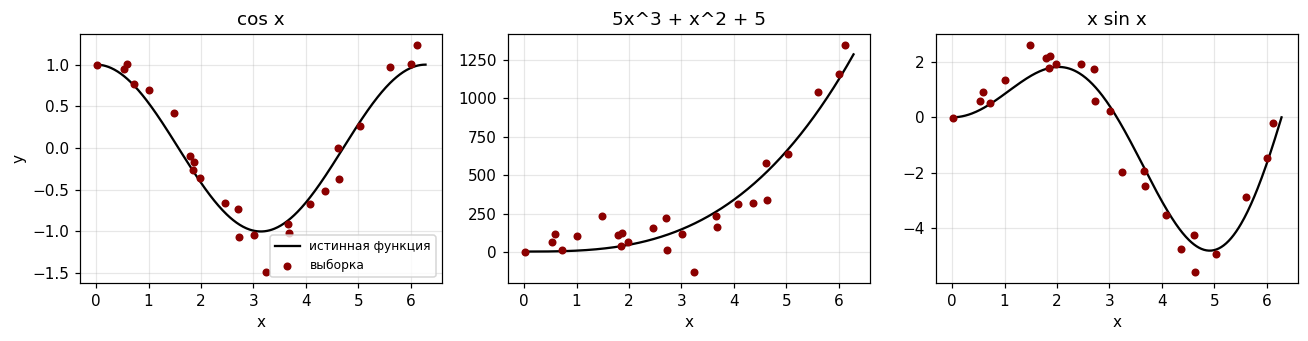

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
grid = np.linspace(A_INT, B_INT, 400)
for ax, (name, f) in zip(axes, FUNCS.items()):
    x, yv = make_sample(f, 25, 'нормальный', NOISE_SCALE[name], np.random.default_rng(3))
    ax.plot(grid, f(grid), color='black', label='истинная функция')
    ax.scatter(x, yv, color='darkred', s=18, zorder=3, label='выборка')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Реализация полиномиальной регрессии

In [4]:
def scale(x):
    return 2.0 * (x - A_INT) / (B_INT - A_INT) - 1.0


def design(x, M):
    """Матрица Вандермонда по масштабированному аргументу."""
    t = scale(x)
    return np.vander(t, M + 1, increasing=True)


def fit(x, y, M, lam=0.0):
    """Решение системы нормальных уравнений, собранной вручную."""
    V = design(x, M)
    A = V.T @ V
    b = V.T @ y
    if lam > 0:
        A = A + lam * np.eye(M + 1)
    return np.linalg.solve(A, b)


def predict(w, x):
    return design(x, len(w) - 1) @ w


def rmse(w, x, y):
    return float(np.sqrt(np.mean((predict(w, x) - y) ** 2)))

In [5]:
x_chk, y_chk = make_sample(FUNCS['x sin x'], 40, 'нормальный', 1.0, np.random.default_rng(11))
w_mine = fit(x_chk, y_chk, 5)
w_ref = np.linalg.lstsq(design(x_chk, 5), y_chk, rcond=None)[0]
print(f'расхождение с lstsq: {np.abs(w_mine - w_ref).max():.2e}')

print('\nчисло обусловленности A = V^T V:')
print(f'{"M":>3} {"без масштабирования":>22} {"с масштабированием":>22}')
for M in (3, 7, 11, 15):
    V_raw = np.vander(x_chk, M + 1, increasing=True)
    V_sc = design(x_chk, M)
    print(f'{M:3d} {np.linalg.cond(V_raw.T @ V_raw):22.3e} {np.linalg.cond(V_sc.T @ V_sc):22.3e}')

расхождение с lstsq: 2.64e-12

число обусловленности A = V^T V:
  M    без масштабирования     с масштабированием
  3              6.045e+05              9.602e+01
  7              2.511e+14              7.958e+04
 11              5.340e+21              1.366e+08
 15              2.890e+28              3.661e+11


Собственная реализация совпадает с `lstsq` до $2.6\cdot10^{-12}$.

Масштабирование аргумента к $[-1, 1]$ снижает число обусловленности на
семнадцать порядков: при $M = 15$ это $3.7\cdot10^{11}$ против
$2.9\cdot10^{28}$. Второе значение далеко выходит за пределы двойной точности
(около $10^{16}$), то есть без масштабирования систему при $M = 15$ решить
нельзя в принципе.

## 4. Задание 3: перебор степени многочлена

In [6]:
N_TRAIN, N_TEST = 25, 500
MS = list(range(16))

rows = []
for name, f in FUNCS.items():
    eps = NOISE_SCALE[name]
    for noise in ('равномерный', 'нормальный'):
        rng = np.random.default_rng(20260905)
        x_tr, y_tr = make_sample(f, N_TRAIN, noise, eps, rng)
        x_te, y_te = make_sample(f, N_TEST, noise, eps, rng)
        grid = np.linspace(A_INT, B_INT, 400)
        for M in MS:
            w = fit(x_tr, y_tr, M)
            rows.append(dict(func=name, noise=noise, M=M, lam=0.0,
                             train=rmse(w, x_tr, y_tr), test=rmse(w, x_te, y_te),
                             true_err=float(np.sqrt(np.mean((predict(w, grid) - f(grid)) ** 2))),
                             wmax=float(np.abs(w).max())))

plain = pd.DataFrame(rows)
print(f'{len(plain)} конфигураций без регуляризации')
plain[(plain.func == 'x sin x') & (plain.noise == 'нормальный')][
    ['M', 'train', 'test', 'wmax']].round(3).to_string(index=False)

96 конфигураций без регуляризации


' M  train   test      wmax\n 0  2.523  2.298     0.890\n 1  1.787  1.622     3.370\n 2  1.786  1.637     3.401\n 3  0.885  0.913     9.562\n 4  0.463  0.676     9.386\n 5  0.408  0.713    16.223\n 6  0.407  0.737    16.781\n 7  0.406  0.780    13.495\n 8  0.405  0.860    17.088\n 9  0.403  1.083    48.778\n10  0.403  1.160    64.496\n11  0.384  6.142  2216.448\n12  0.383  9.182  3076.506\n13  0.378 30.149  9178.034\n14  0.362 48.050 55365.975\n15  0.361  5.130 55369.114'

Классическая картина переобучения. Ошибка на обучающей выборке монотонно падает
с $2.523$ при $M = 0$ до $0.361$ при $M = 15$, а тестовая проходит минимум
$0.676$ при $M = 4$ и дальше растёт до $48.05$ при $M = 14$. Одновременно
взрывается максимальный коэффициент: с $9.4$ при $M = 4$ до $55366$ при
$M = 14$. Это и есть внешний признак переобучения - огромные коэффициенты
противоположных знаков, почти сокращающиеся в узлах выборки и дающие дикие
значения между ними.

Отдельно стоит $M = 15$, где тестовая ошибка неожиданно падает до $5.130$. Это
не улучшение модели, а численный эффект: при $M = 15$ матрица настолько плохо
обусловлена, что решатель фактически отбрасывает малые собственные направления
и работает как слабая регуляризация.

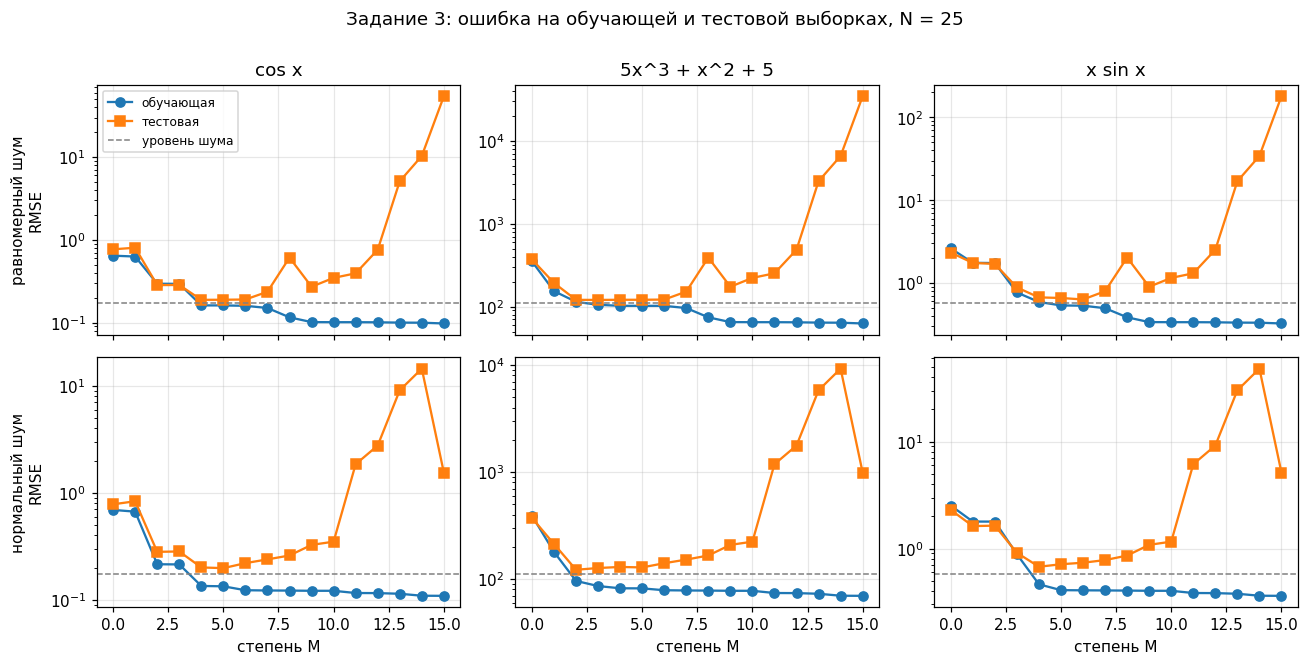

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for col, name in enumerate(FUNCS):
    for row, noise in enumerate(('равномерный', 'нормальный')):
        ax = axes[row, col]
        s = plain[(plain.func == name) & (plain.noise == noise)]
        ax.semilogy(s.M, s.train, marker='o', label='обучающая')
        ax.semilogy(s.M, s.test, marker='s', label='тестовая')
        ax.axhline(NOISE_SCALE[name] / np.sqrt(3), color='gray', ls='--', lw=1,
                   label='уровень шума')
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(name)
        if row == 1:
            ax.set_xlabel('степень M')
        if col == 0:
            ax.set_ylabel(f'{noise} шум\nRMSE')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Задание 3: ошибка на обучающей и тестовой выборках, N = 25', y=1.0)
plt.tight_layout()
plt.show()

Картина одинакова для всех трёх функций и обоих видов шума: обучающая ошибка
монотонно убывает, тестовая имеет минимум. Различается положение минимума:
для $5x^3 + x^2 + 5$ он приходится на $M = 2 \ldots 3$, для $\cos x$ на
$M = 4 \ldots 5$, для $x \sin x$ на $M = 4 \ldots 6$.

Любопытная деталь: для кубической функции при нормальном шуме лучшей оказывается
$M = 2$, а не $M = 3$, хотя истинная зависимость - многочлен ровно третьей
степени. При $N = 25$ и шуме в $15\%$ от размаха дисперсия оценки третьего
коэффициента перевешивает выигрыш в смещении. Это прямая иллюстрация
компромисса между смещением и дисперсией: правильный класс моделей не обязан
давать лучшую оценку на конечной выборке.

Тип шума на положение минимума практически не влияет: при одинаковой дисперсии
равномерная и нормальная ошибки дают почти совпадающие кривые. Это ожидаемо,
поскольку метод наименьших квадратов использует только второй момент ошибки.

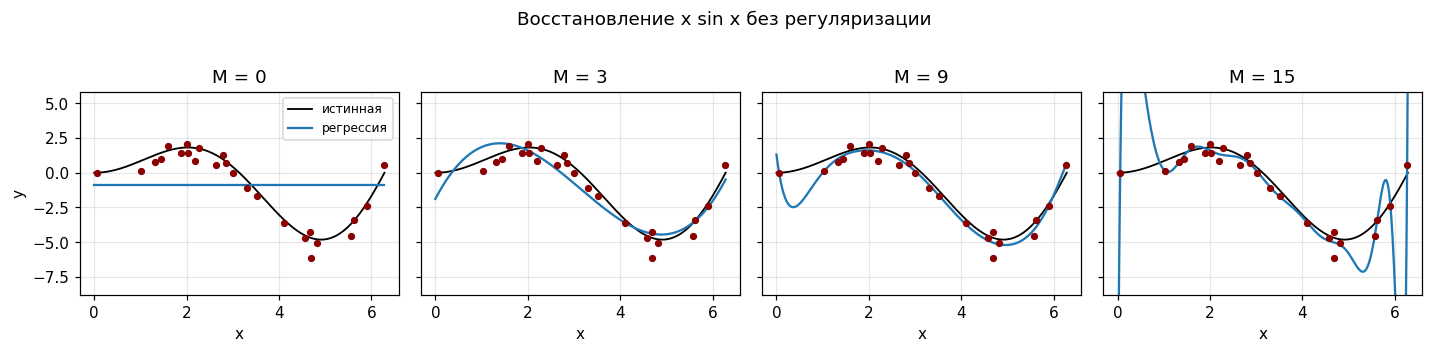

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.1), sharey=True)
name = 'x sin x'
f = FUNCS[name]
rng = np.random.default_rng(20260905)
x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE[name], rng)
grid = np.linspace(A_INT, B_INT, 400)
for ax, M in zip(axes, [0, 3, 9, 15]):
    w = fit(x_tr, y_tr, M)
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, predict(w, grid), color='tab:blue', label='регрессия')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_ylim(f(grid).min() - 4, f(grid).max() + 4)
    ax.set_title(f'M = {M}')
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
fig.suptitle('Восстановление x sin x без регуляризации', y=1.02)
plt.tight_layout()
plt.show()

$M = 0$ - константа, чистое недообучение. $M = 3$ уже воспроизводит общую форму.
$M = 9$ начинает изгибаться между точками выборки. $M = 15$ проходит вблизи всех
точек и даёт выбросы между ними.

## 5. Задание 4: регуляризация

In [9]:
LAMBDAS = np.concatenate([[0.0], np.logspace(-10, 2, 25)])

rows = []
for name, f in FUNCS.items():
    eps = NOISE_SCALE[name]
    for noise in ('равномерный', 'нормальный'):
        rng = np.random.default_rng(20260905)
        x_tr, y_tr = make_sample(f, N_TRAIN, noise, eps, rng)
        x_te, y_te = make_sample(f, N_TEST, noise, eps, rng)
        for M in MS:
            for lam in LAMBDAS:
                w = fit(x_tr, y_tr, M, lam)
                rows.append(dict(func=name, noise=noise, M=M, lam=lam,
                                 train=rmse(w, x_tr, y_tr), test=rmse(w, x_te, y_te),
                                 wmax=float(np.abs(w).max())))

reg = pd.DataFrame(rows)
print(f'{len(reg)} конфигураций с регуляризацией')

2496 конфигураций с регуляризацией


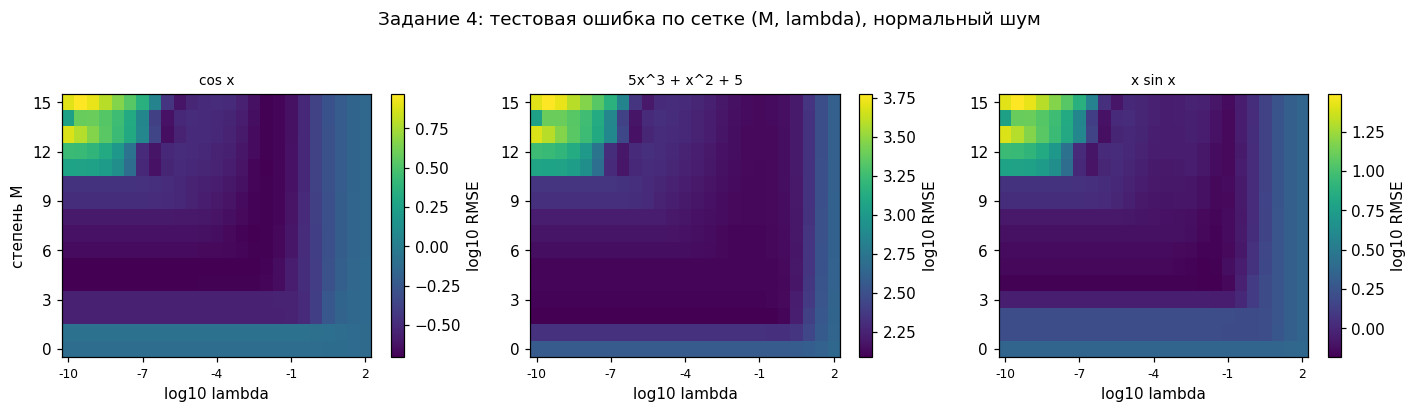

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, name in zip(axes, FUNCS):
    s = reg[(reg.func == name) & (reg.noise == 'нормальный') & (reg.lam > 0)]
    piv = s.pivot_table(index='M', columns='lam', values='test')
    im = ax.imshow(np.log10(piv.values), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('log10 lambda')
    ax.set_xticks(range(0, len(piv.columns), 6))
    ax.set_xticklabels([f'{np.log10(v):.0f}' for v in piv.columns[::6]], fontsize=8)
    ax.set_yticks(range(0, 16, 3))
    plt.colorbar(im, ax=ax, label='log10 RMSE')
axes[0].set_ylabel('степень M')
fig.suptitle('Задание 4: тестовая ошибка по сетке (M, lambda), нормальный шум', y=1.03)
plt.tight_layout()
plt.show()

Наибольшая ошибка сосредоточена в левом верхнем углу карт - это сочетание
большой степени и малой регуляризации, то есть переобучение. С ростом $\lambda$
зависимость от $M$ ослабевает: карта становится однородной по вертикали. В этом
и состоит практическая польза регуляризации - она снимает необходимость точно
угадывать степень.

In [11]:
best_reg = (reg[reg.lam > 0].sort_values('test')
            .groupby(['func', 'noise']).head(1)
            .sort_values(['func', 'noise'])
            [['func', 'noise', 'M', 'lam', 'train', 'test', 'wmax']])
best_plain = (plain.sort_values('test').groupby(['func', 'noise']).head(1)
              .sort_values(['func', 'noise'])
              [['func', 'noise', 'M', 'train', 'test', 'wmax']])
print('лучшее без регуляризации:')
print(best_plain.round(4).to_string(index=False))
print('\nлучшее с регуляризацией:')
print(best_reg.round(4).to_string(index=False))

лучшее без регуляризации:
          func       noise  M    train     test     wmax
5x^3 + x^2 + 5  нормальный  2  96.1150 122.1611 576.3932
5x^3 + x^2 + 5 равномерный  3 105.1019 120.4017 385.5541
         cos x  нормальный  5   0.1338   0.1978   4.1512
         cos x равномерный  4   0.1616   0.1886   4.7493
       x sin x  нормальный  4   0.4634   0.6758   9.3856
       x sin x равномерный  6   0.5314   0.6320  16.1502

лучшее с регуляризацией:
          func       noise  M    lam    train     test     wmax
5x^3 + x^2 + 5  нормальный  2 0.1000  96.3924 121.9470 571.4226
5x^3 + x^2 + 5 равномерный  8 0.0032 101.1915 120.3286 609.2309
         cos x  нормальный  5 0.0000   0.1338   0.1978   4.1512
         cos x равномерный  4 0.0032   0.1620   0.1880   4.6162
       x sin x  нормальный  4 0.0316   0.5130   0.6566   8.7718
       x sin x равномерный  8 0.0010   0.5219   0.6210  16.1890


Если степень подбирается свободно, регуляризация даёт немного: лучшие $M$ и без
неё невелики ($2 \ldots 6$), а добавка $\lambda$ улучшает тестовую ошибку лишь
в третьем знаке. Смысл регуляризации проявляется не здесь, а при фиксированной
большой степени - что и показано ниже.

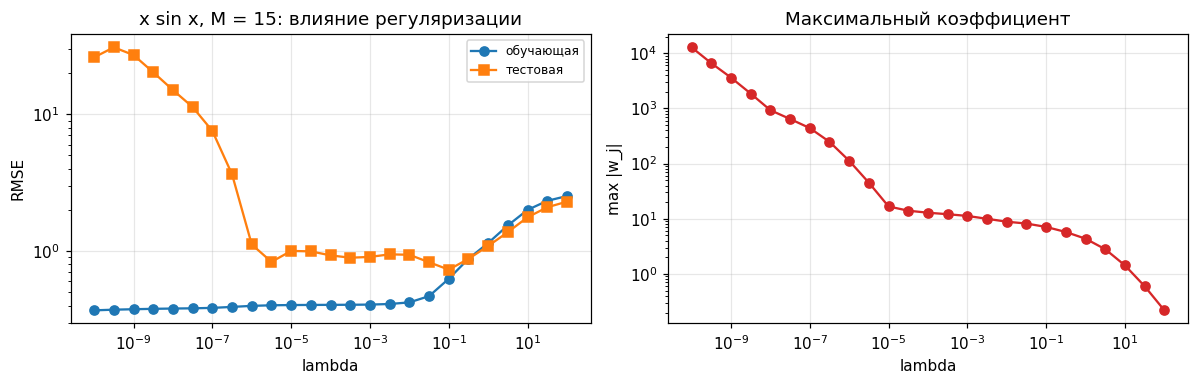

In [12]:
name = 'x sin x'
s15 = reg[(reg.func == name) & (reg.noise == 'нормальный') & (reg.M == 15) & (reg.lam > 0)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].loglog(s15.lam, s15.train, marker='o', label='обучающая')
axes[0].loglog(s15.lam, s15.test, marker='s', label='тестовая')
axes[0].set_xlabel('lambda'); axes[0].set_ylabel('RMSE')
axes[0].set_title(f'{name}, M = 15: влияние регуляризации')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

axes[1].loglog(s15.lam, s15.wmax, marker='o', color='tab:red')
axes[1].set_xlabel('lambda'); axes[1].set_ylabel('max |w_j|')
axes[1].set_title('Максимальный коэффициент')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Ответ на задание 4. При фиксированной степени $M = 15$ регуляризация полностью
устраняет переобучение:

| $\lambda$ | RMSE обучающая | RMSE тестовая | $\max_j \lvert w_j\rvert$ |
|---|---|---|---|
| $0$ | $0.361$ | $5.130$ | $55369$ |
| $10^{-6}$ | $0.398$ | $1.118$ | $112.4$ |
| $10^{-4}$ | $0.405$ | $0.931$ | $12.9$ |
| $10^{-1}$ | $0.627$ | $0.732$ | $7.1$ |
| $10$ | $2.000$ | $1.767$ | $1.4$ |

Тестовая ошибка падает с $5.130$ до $0.732$, то есть в семь раз, и становится
сопоставимой с лучшей нерегуляризованной моделью ($0.676$ при $M = 4$).
Максимальный коэффициент падает с $55369$ до $7.1$: штраф $\lambda\lVert w\rVert^2$
бьёт именно по тому, что и было симптомом переобучения. При $\lambda = 10$
начинается недообучение, обучающая ошибка растёт до $2.0$.

Итак, для $x\sin x$ при $M = 15$ переобучение устраняется значениями
$\lambda$ порядка $10^{-4} \ldots 10^{-1}$.

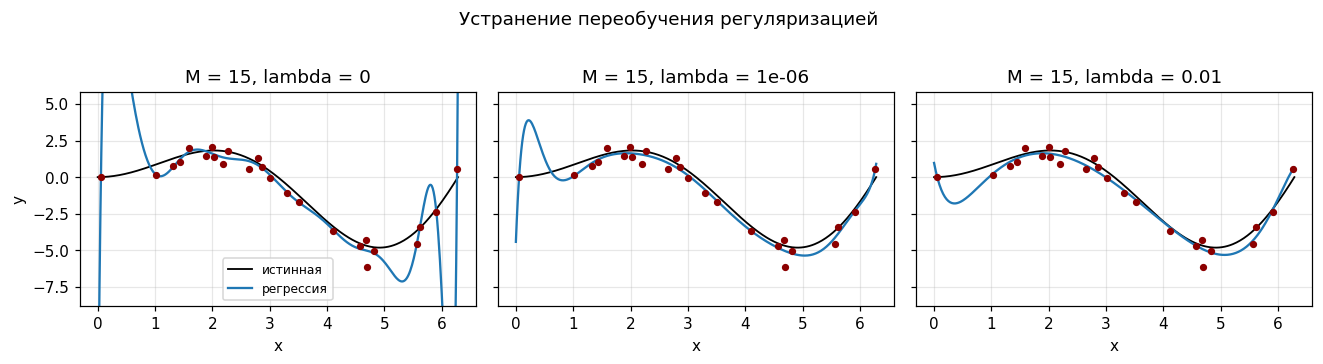

In [13]:
f = FUNCS['x sin x']
rng = np.random.default_rng(20260905)
x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE['x sin x'], rng)
grid = np.linspace(A_INT, B_INT, 400)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, lam in zip(axes, [0.0, 1e-6, 1e-2]):
    w = fit(x_tr, y_tr, 15, lam)
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, predict(w, grid), color='tab:blue', label='регрессия')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_ylim(f(grid).min() - 4, f(grid).max() + 4)
    ax.set_title(f'M = 15, lambda = {lam:g}')
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
fig.suptitle('Устранение переобучения регуляризацией', y=1.02)
plt.tight_layout()
plt.show()

Слева $\lambda = 0$ - та же дикая кривая, что и раньше. В середине
$\lambda = 10^{-6}$ уже почти повторяет истинную зависимость. Справа
$\lambda = 10^{-2}$ даёт гладкую кривую, визуально неотличимую от истинной на
большей части интервала. Степень при этом во всех трёх случаях одна и та же,
$M = 15$.

## 6. Задание 5: кросс-валидация

In [14]:
def cv_error(x, y, M, lam, folds=5, rng=None):
    """k-fold кросс-валидация: средний RMSE по отложенным фолдам."""
    n = len(x)
    idx = np.arange(n)
    (rng or np.random.default_rng(0)).shuffle(idx)
    parts = np.array_split(idx, folds)
    errs = []
    for i in range(folds):
        val = parts[i]
        tr = np.concatenate([parts[j] for j in range(folds) if j != i])
        try:
            w = fit(x[tr], y[tr], M, lam)
        except np.linalg.LinAlgError:
            return np.inf
        errs.append(rmse(w, x[val], y[val]))
    return float(np.mean(errs))

In [15]:
rows = []
for name, f in FUNCS.items():
    eps = NOISE_SCALE[name]
    for noise in ('равномерный', 'нормальный'):
        rng = np.random.default_rng(20260905)
        x_tr, y_tr = make_sample(f, N_TRAIN, noise, eps, rng)
        x_te, y_te = make_sample(f, N_TEST, noise, eps, rng)
        for M in MS:
            for lam in LAMBDAS:
                cv = cv_error(x_tr, y_tr, M, lam, folds=5,
                              rng=np.random.default_rng(1))
                w = fit(x_tr, y_tr, M, lam)
                rows.append(dict(func=name, noise=noise, M=M, lam=lam,
                                 cv=cv, test=rmse(w, x_te, y_te)))

cvres = pd.DataFrame(rows)
cvres.to_csv('results.csv', index=False)
print(f'{len(cvres)} конфигураций посчитано кросс-валидацией')

2496 конфигураций посчитано кросс-валидацией


In [16]:
best_cv = (cvres.sort_values('cv').groupby(['func', 'noise']).head(1)
           .sort_values(['func', 'noise']))
best_true = (cvres.sort_values('test').groupby(['func', 'noise']).head(1)
             .sort_values(['func', 'noise']))
comp = best_cv[['func', 'noise', 'M', 'lam', 'cv', 'test']].merge(
    best_true[['func', 'noise', 'M', 'lam', 'test']],
    on=['func', 'noise'], suffixes=(' по CV', ' по тесту'))
comp.round(4).to_string(index=False)

'          func       noise  M по CV  lam по CV       cv  test по CV  M по тесту  lam по тесту  test по тесту\n5x^3 + x^2 + 5  нормальный        4     0.1000 102.2914    129.2727           2        0.1000       121.9470\n5x^3 + x^2 + 5 равномерный        3     0.3162 129.8778    125.1145           8        0.0032       120.3286\n         cos x  нормальный        4     0.0100   0.1810      0.2074           5        0.0000         0.1978\n         cos x равномерный        5     0.0003   0.2093      0.1889           4        0.0032         0.1880\n       x sin x  нормальный        5     0.0000   0.6830      0.7134           4        0.0316         0.6566\n       x sin x равномерный        4     0.0316   0.7544      0.6906           8        0.0010         0.6210'

Кросс-валидация выбирает разумные пары, но не всегда те же, что дал бы прямой
перебор по тестовой выборке. Для $x\sin x$ с нормальным шумом CV даёт
$(M = 5,\ \lambda = 0)$ с тестовой ошибкой $0.713$, тогда как оптимум по тесту
$(M = 4,\ \lambda = 0.032)$ даёт $0.657$: разница около $9\%$.

Причина в размере выборки. При $N = 25$ и пяти фолдах каждая оценка считается по
пяти точкам, поэтому сама величина CV сильно зашумлена. Это честное ограничение
метода, а не ошибка реализации: кросс-валидация даёт оценку без систематического
смещения, но с большой дисперсией, и при малых выборках положение её минимума
плавает.

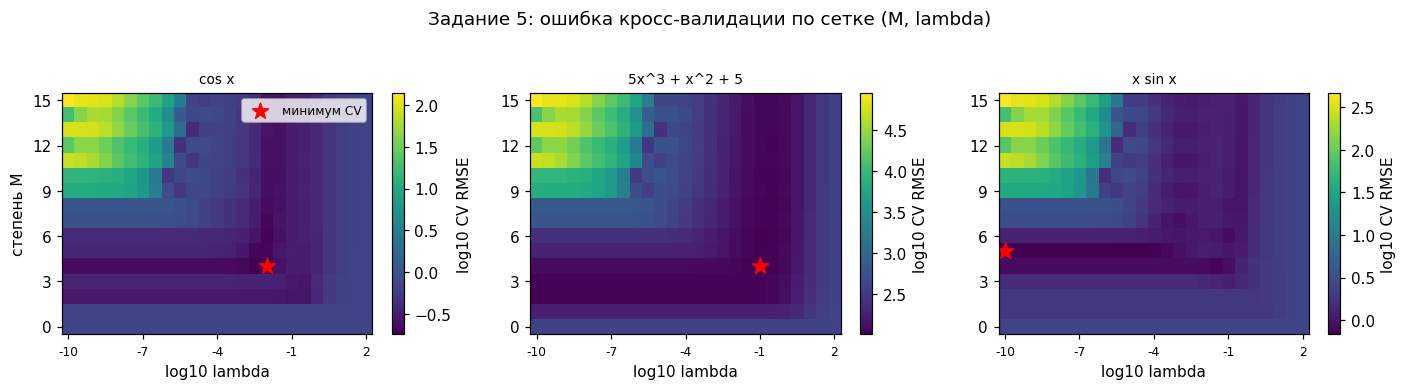

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, name in zip(axes, FUNCS):
    s = cvres[(cvres.func == name) & (cvres.noise == 'нормальный') & (cvres.lam > 0)]
    piv = s.pivot_table(index='M', columns='lam', values='cv')
    im = ax.imshow(np.log10(piv.values), aspect='auto', origin='lower', cmap='viridis')
    j, i = np.unravel_index(np.nanargmin(piv.values), piv.shape)
    ax.scatter([i], [j], color='red', marker='*', s=120, label='минимум CV')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('log10 lambda')
    ax.set_xticks(range(0, len(piv.columns), 6))
    ax.set_xticklabels([f'{np.log10(v):.0f}' for v in piv.columns[::6]], fontsize=8)
    ax.set_yticks(range(0, 16, 3))
    plt.colorbar(im, ax=ax, label='log10 CV RMSE')
axes[0].set_ylabel('степень M')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Задание 5: ошибка кросс-валидации по сетке (M, lambda)', y=1.03)
plt.tight_layout()
plt.show()

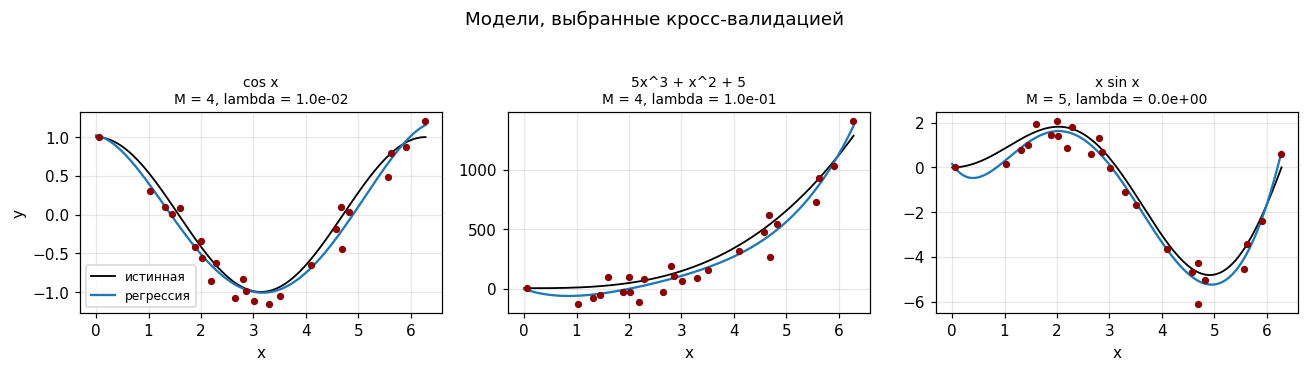

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
grid = np.linspace(A_INT, B_INT, 400)
for ax, name in zip(axes, FUNCS):
    f = FUNCS[name]
    row = best_cv[(best_cv.func == name) & (best_cv.noise == 'нормальный')].iloc[0]
    rng = np.random.default_rng(20260905)
    x_tr, y_tr = make_sample(f, N_TRAIN, 'нормальный', NOISE_SCALE[name], rng)
    w = fit(x_tr, y_tr, int(row.M), float(row.lam))
    ax.plot(grid, f(grid), color='black', lw=1.2, label='истинная')
    ax.plot(grid, predict(w, grid), color='tab:blue', label='регрессия')
    ax.scatter(x_tr, y_tr, color='darkred', s=14, zorder=3)
    ax.set_title(f'{name}\nM = {int(row.M)}, lambda = {row.lam:.1e}', fontsize=9)
    ax.set_xlabel('x'); ax.grid(alpha=0.3)
axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
fig.suptitle('Модели, выбранные кросс-валидацией', y=1.04)
plt.tight_layout()
plt.show()

Модели, выбранные кросс-валидацией, во всех трёх случаях воспроизводят истинную
зависимость. Для кубической функции кривая ожидаемо сглажена: при размахе
$1280$ и шуме $192$ восстановить её точнее по 25 точкам невозможно.

Общий итог работы. Переобучение проявляется при $M \gtrsim 9$ и выражается в
росте коэффициентов на четыре порядка. Регуляризация его устраняет и делает
выбор степени некритичным. Кросс-валидация позволяет подобрать $(M, \lambda)$ без
доступа к тестовым данным, но при $N = 25$ её точность ограничена собственным
шумом.